# Predictor-corrector method for the advection-diffusion equation

$$
\mathbb{S}_{u,\textbf{a}}=\begin{cases}
\Omega = [0, L_x] \\
u_0(x) = \exp\left(-\frac{(x-x_0)^2}{L_x/100}\right) \\
u_{\text{D}}(x=0) = 0 \\
u_{\text{D}}(x=L_x) = 0 \\
\textbf{a} = a\,\textbf{e}_x \\
\mathscr{L}_{x}(a, u) = \frac{\partial^2 a}{\partial x^2} - ku^2 \\
a_{\text{D}}(x=0) = 0 \\
a_{\text{D}}(x=L_x) = 0 \\
\mathsf{D} = D\mathsf{I} \\
\end{cases}
$$

In [ ]:
import numpy as np
from ufl import as_vector
from lucifex.mesh import interval_mesh, mesh_boundary
from lucifex.fdm import (
    CN, FE, BE, ExplicitFiniteDifference, ImplicitFiniteDifference, FiniteDifference,
    FunctionSeries, ConstantSeries, finite_difference_order,
)
from lucifex.fem import Constant
from lucifex.solver import bvp, ibvp, evaluation, BoundaryConditions
from lucifex.sim import run, Simulation
from lucifex.plt import plot_line, save_figure
from lucifex.utils.npy_utils import as_index
from lucifex.pde.advection_diffusion import advection_diffusion
from lucifex.pde.poisson import poisson

def create_simulation(
    Lx: float,
    Nx: int,
    dt: float,
    d: float,
    k: float,
    D_adv: ExplicitFiniteDifference,
    D_diff: FiniteDifference,
    D_adv_corr: ImplicitFiniteDifference | None,
) -> Simulation:
    order = finite_difference_order(D_adv, D_diff)
    mesh = interval_mesh(Lx, Nx)
    dOmega = mesh_boundary(
        mesh, 
        {
            'left': lambda x: x[0],
            'right': lambda x: x[0] - Lx,
        }
    )
    t = ConstantSeries(mesh, name='t', ics=0.0)
    dt = Constant(mesh, dt, name='dt')
    d = Constant(mesh, d, name='d')
    k = Constant(mesh, k, name='k')
    u_ics = lambda x: np.exp(-(x[0] - 0.5 * Lx)**2 / (0.05 * Lx))
    u_bcs = BoundaryConditions(
        ('dirichlet', dOmega.union, 0.0),
    )
    a_bcs = BoundaryConditions(
        ('dirichlet', dOmega.union, 0.0),
    )
    u = FunctionSeries((mesh, 'P', 1), name='u', order=order, store=1, ics=u_ics)
    a = FunctionSeries((mesh, 'P', 1, 1), name='a', order=order, store=1)

    if D_adv_corr is None:
        a_solver = bvp(poisson, a_bcs)(a, as_vector([k * u[0]**2]))
        u_solver = ibvp(advection_diffusion, bcs=u_bcs)(
            u, dt, a, d, D_adv, D_diff,
        )
        solvers = (a_solver, u_solver)
    else:
        uTilde = FunctionSeries(u.function_space, name='u', order=order)
        aTilde = FunctionSeries(a.function_space)
        evaluator = lambda u: u
        a_solver = bvp(poisson, a_bcs)(
            a, as_vector([k * u[0]**2]),
        )
        uTilde_setter = evaluation(uTilde, evaluator, future=False, overwrite=True)(
            u[0]
        )
        uTilde_solver = ibvp(advection_diffusion, bcs=u_bcs)(
            uTilde, dt, a, d, D_adv, D_diff,
        )
        aTilde_solver = bvp(poisson, a_bcs, future=True)(
            aTilde, as_vector([k * uTilde[1]**2]),
        )
        u_solver = ibvp(advection_diffusion, bcs=u_bcs)(
            u, dt, aTilde, d, D_adv_corr, D_diff,
        )
        solvers = (a_solver, uTilde_setter, uTilde_solver, aTilde_solver, u_solver)

    return Simulation(solvers, t, dt)


Lx = 2.0
Nx = 50
dt = 0.01
d = 0.1
k = 10.0

D_adv = FE
D_diff = CN
D_adv_corr_opts = (None, BE)
simulations: dict[None | ExplicitFiniteDifference, Simulation] = {}

for D_adv_corr in D_adv_corr_opts:
    simulations[D_adv_corr] = create_simulation(Lx, Nx, dt, d, k, D_adv, D_diff, D_adv_corr)
    
n_init = 5
n_stop = 50
for D_adv_corr in D_adv_corr_opts:
    run(simulations[D_adv_corr], n_stop, n_init=n_init)

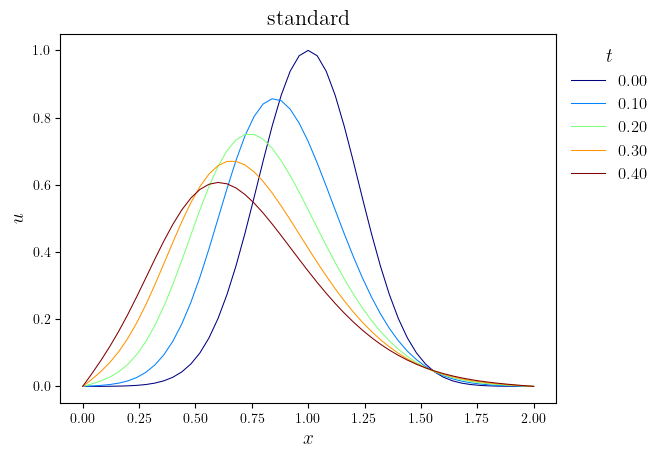

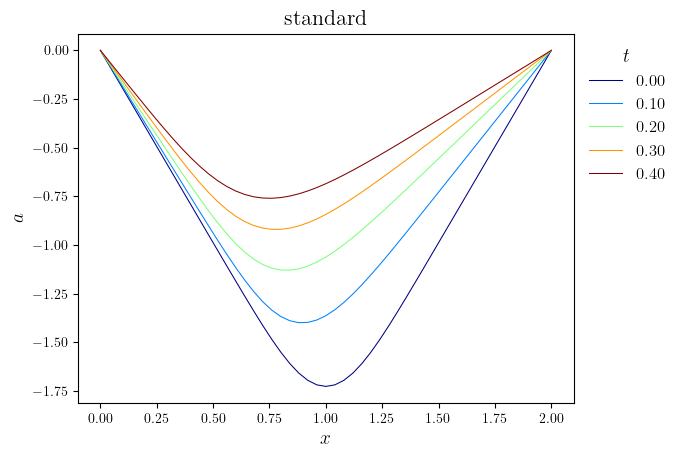

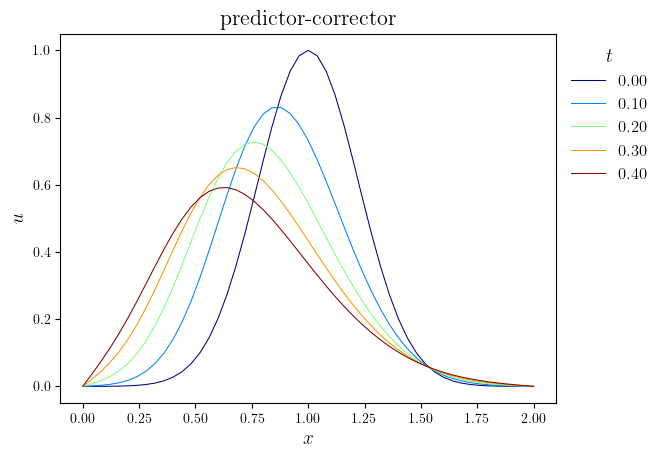

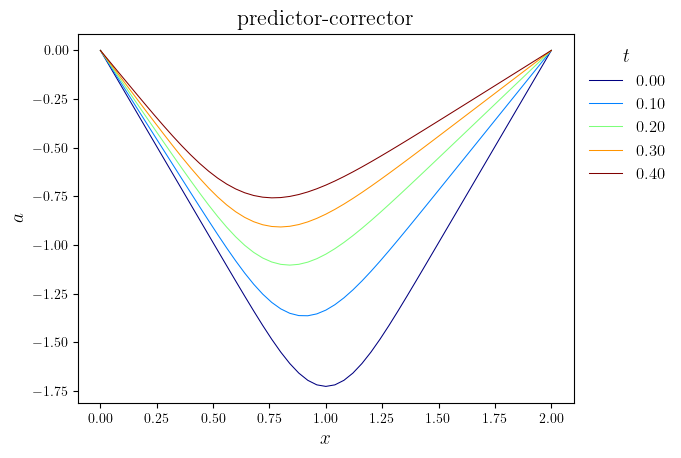

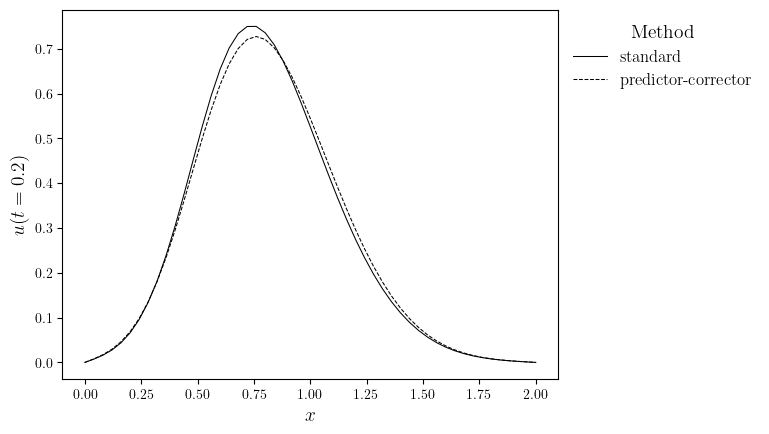

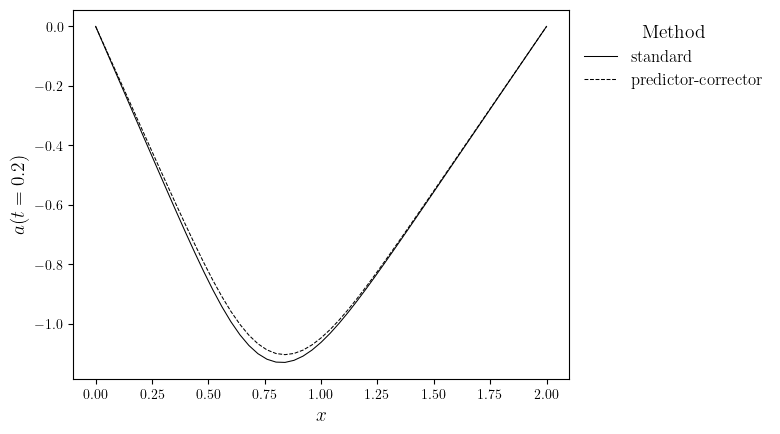

: 

In [ ]:
slc = slice(0, None, 10)

line_kws = dict(
    x_label='$x$',
    cyc='jet',
    legend_title='$t$',
)
t_target = 20 * dt

labels = ['standard', 'predictor-corrector']
u_lines, a_lines = [], []

for lbl, (D_adv_corr, sim) in zip(labels, simulations.items()):
    u, a_vec = sim['u', 'a']
    (a, ) = a_vec.split()
    legend_labels = [f"{time:.2f}" for time in u.time_series[slc]]
    fig, ax = plot_line(
        u.series[slc], 
        y_label='$u$',
        legend_labels=[f"{time:.2f}" for time in u.time_series[slc]],
        title=lbl,
        **line_kws,
    )
    save_figure(f'u(x,t)_{repr(D_adv_corr)}')(fig)
    fig, ax = plot_line(
        a.series[slc], 
        y_label='$a$',
        legend_labels=[f"{time:.2f}" for time in u.time_series[slc]],
        title=lbl,
        **line_kws,
    )
    save_figure(f'a(x,t)_{repr(D_adv_corr)}')(fig)
    u_time_idx = as_index(u.time_series, t_target)
    u_lines.append(u.series[u_time_idx])
    ax_time_idx = as_index(a.time_series, t_target)
    a_lines.append(a.series[ax_time_idx])


line_kws = dict(
    x_label='$x$',
    cyc='black',
    legend_title='Method',
    legend_labels=labels,
)
fig, ax = plot_line(
    u_lines, 
    y_label=f'$u(t={t_target})$',
    **line_kws,
)
save_figure(f'u(x,t={t_target:.3f})', thumbnail=True)(fig)
fig, ax = plot_line(
    a_lines, 
    y_label=f'$a(t={t_target})$',
    **line_kws,
)
save_figure(f'a(x,t={t_target:.3f})')(fig)